This project analyzes customer return behavior in e-commerce transactions to identify suspicious return patterns using Python and data visualization.

In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


In [2]:
#dataset generation
np.random.seed(42)

n = 5000

data = {
    "customer_id": np.random.randint(1000, 1100, n),
    "order_value": np.random.randint(200, 5000, n),
    "product_category": np.random.choice(
        ["Electronics","Clothing","Beauty","Home","Sports"], n
    ),
    "returned": np.random.choice([0,1], n, p=[0.85,0.15])
}

df = pd.DataFrame(data)

df.head()

,customer_id,order_value,product_category,returned
0,1051,1436,Clothing,0
1,1092,336,Home,0
2,1014,1229,Sports,0
3,1071,2356,Home,0
4,1060,2794,Electronics,1


In [3]:
df.shape


(5000, 4)

In [4]:
#dataset inspection
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customer_id       5000 non-null   int64 
 1   order_value       5000 non-null   int64 
 2   product_category  5000 non-null   object
 3   returned          5000 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 156.4+ KB


In [5]:
#customer return rate analysis
return_rate = df.groupby("customer_id")["returned"].mean().sort_values(ascending=False)

return_rate.head(10)


,returned
customer_id,
1049,0.272727
1048,0.272727
1032,0.245902
1011,0.245283
1073,0.239130
1055,0.232558
1030,0.225806
1033,0.224490
1042,0.222222


In [13]:
#fraud_detection logic
fraud_customers = return_rate.head(10)

fraud_customers

,returned
customer_id,
1049,0.272727
1048,0.272727
1032,0.245902
1011,0.245283
1073,0.239130
1055,0.232558
1030,0.225806
1033,0.224490
1042,0.222222


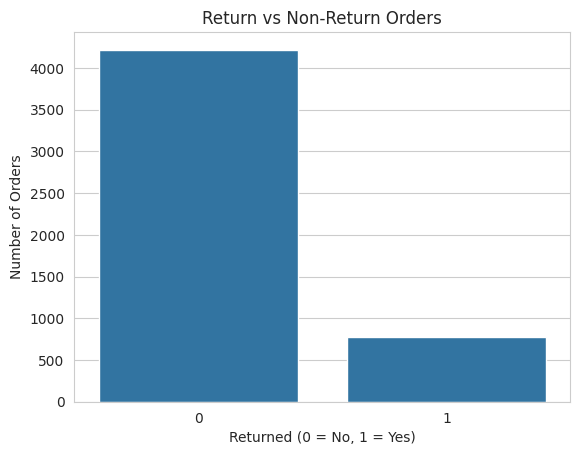

In [14]:
#data visualisation
sns.countplot(x=df["returned"])
plt.title("Return vs Non-Return Orders")
plt.xlabel("Returned (0 = No, 1 = Yes)")
plt.ylabel("Number of Orders")
plt.show()

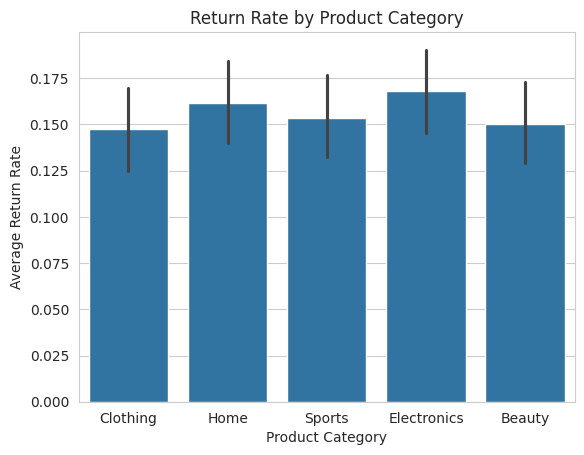

In [15]:
sns.barplot(x="product_category", y="returned", data=df)
plt.title("Return Rate by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Return Rate")
plt.show()

In [16]:
return_rate.head(10)

,returned
customer_id,
1049,0.272727
1048,0.272727
1032,0.245902
1011,0.245283
1073,0.239130
1055,0.232558
1030,0.225806
1033,0.224490
1042,0.222222


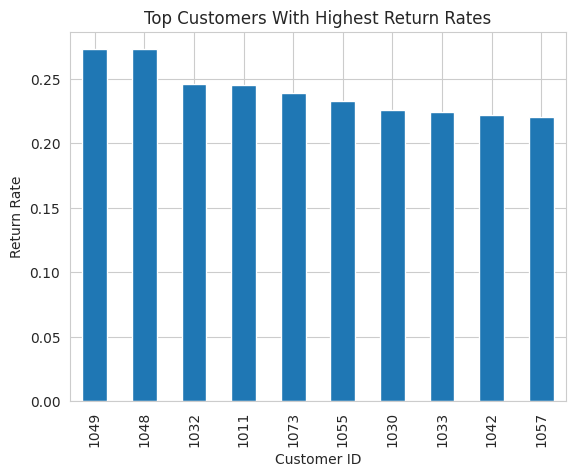

In [17]:
return_rate.head(10).plot(kind="bar")

plt.title("Top Customers With Highest Return Rates")
plt.xlabel("Customer ID")
plt.ylabel("Return Rate")

plt.show()

In [9]:
#insights and conclusion
print("Key Insights from E-commerce Return Fraud Analysis")

print("1. Majority of orders are not returned, indicating normal customer behavior.")
print("2. Some customers show unusually high return rates, which may indicate potential fraud.")
print("3. Certain product categories show slightly higher return behavior.")
print("4. Customers with return rates greater than 60% are flagged as suspicious.")

Key Insights from E-commerce Return Fraud Analysis
1. Majority of orders are not returned, indicating normal customer behavior.
2. Some customers show unusually high return rates, which may indicate potential fraud.
3. Certain product categories show slightly higher return behavior.
4. Customers with return rates greater than 60% are flagged as suspicious.
